In [50]:
from sklearn.datasets import fetch_california_housing
##一个基于MLP预测加利福尼亚房价的小项目，使用sklearn的自带数据集

In [51]:
data = fetch_california_housing()

X = data.data
y = data.target

In [52]:
type(data)

sklearn.utils._bunch.Bunch

In [53]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [54]:
data.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [55]:
data.data.shape

(20640, 8)

In [56]:
data.target##这是预测目标，即y值

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [57]:
data.feature_names##每个特征名字

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [58]:
print(data.DESCR)##数据集说明书

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [59]:
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)##列标签为feature_names,
df["target"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [60]:
df.isnull().sum()##检查空白值

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'target'}>]], dtype=object)

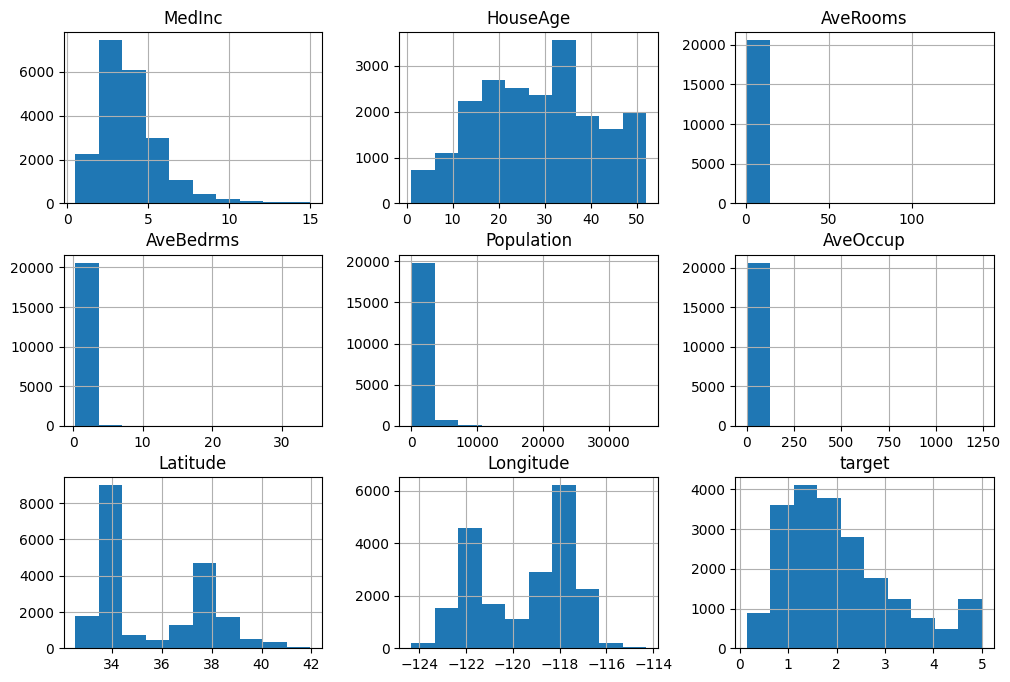

In [61]:
df.hist(figsize=(12,8))##直方图

In [62]:
y=data.target
x=data.data

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 切分数据
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42##随机数种子,用42是一个梗（《银河系漫游指南》）
)##20%用于训练集

# 标准化
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)#标准化使得梯度忽略量纲影响，可以使用其他研究的学习率统一参考，使数据高斯分布，这里计算出了u和标准差，下一行用
x_test = scaler.transform(x_test)#由于两个集合中样本不同，因此应该使用同一u和方差进行标准化（训练集的），这个代码就是这个意思

In [64]:
x_train.shape

(16512, 8)

In [68]:
y_train.shape

torch.Size([16512, 1])

In [67]:
import torch
##NumPy → Torch Tensor，转化成张量，torch才支持

x_train = torch.tensor(x_train, dtype=torch.float32)##GPU优化32位和16位更好，整个深度学习生态都支持32位浮点数，固定用，nn.Linear也要求32位
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)#.unsqueeze(1)插入新维度
type(x_train)

torch.Tensor

In [70]:
y_test.shape

torch.Size([4128, 1])

In [71]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(x_train, y_train)##捆绑x，y

train_loader = DataLoader(##自动化，进入之前的内容
    train_ds,
    batch_size=64,
    shuffle=True
)

In [79]:
##MLP都这样，MNIST之前也是这样做的，但是8个特征不要dropout，放学不全，MNIST特征多才dropout，这里神经元少dropout杀死的比例要小
#更科学的方法是看到训练集loss下降，但是测试集loss上升，说明出现过拟合时杀神经元
from torch import nn
import torch.nn.functional as F

class HousingNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(8, 64)
        self.fc2 = nn.Linear(64, 32)##数学论证过MLP两层够逼近所有函数
        self.out = nn.Linear(32, 1)
       # self.dropout=nn.Dropout(0.05)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        #x = self.dropout(x)
        x = F.relu(self.fc2(x))
        #x = self.dropout(x)
        x = self.out(x)
        return x

In [94]:
model = HousingNet()

loss_fn = nn.MSELoss()        # 计算均方差，这里创建实例，直接面向对象，省内存


In [95]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)##放另一个cell，调整学习率手动模拟预热，粗训练到小步走的过程，或者用下一个cell，Adma默认推荐0.001

In [96]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)##如果 3 个 epoch 没进步 → lr 自动减半

In [100]:
epochs = 20
for epoch in range(epochs):

    model.train()##开启训练模式
    total_loss = 0

    for xb, yb in train_loader:

        pred = model(xb)          # 前向传播

        loss = loss_fn(pred, yb)  # 算误差

        optimizer.zero_grad()     # 清梯度
        loss.backward()           # 反向传播
        optimizer.step()          # 更新参数

        total_loss += loss.item()   
    # ===== TEST =====
    model.eval()
    with torch.no_grad():
        pred_test = model(x_test)
        test_loss = loss_fn(pred_test, y_test)
        
    scheduler.step(test_loss)##检查loss是否在下降
    # 打印学习率（关键观察）
    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"epoch {epoch} | "
        f"train loss={total_loss:.4f} | "
        f"test loss={test_loss.item():.4f} | "
        f"lr={current_lr}"
    )
    

epoch 0 | train loss=68.4608 | test loss=0.2781 | lr=0.001
epoch 1 | train loss=68.4314 | test loss=0.2871 | lr=0.001
epoch 2 | train loss=68.2131 | test loss=0.2787 | lr=0.001
epoch 3 | train loss=67.7643 | test loss=0.2763 | lr=0.001
epoch 4 | train loss=68.5200 | test loss=0.2754 | lr=0.001
epoch 5 | train loss=67.2555 | test loss=0.2727 | lr=0.001
epoch 6 | train loss=67.0512 | test loss=0.2754 | lr=0.001
epoch 7 | train loss=66.5996 | test loss=0.2845 | lr=0.001
epoch 8 | train loss=66.8514 | test loss=0.2756 | lr=0.001
epoch 9 | train loss=66.6903 | test loss=0.2704 | lr=0.001
epoch 10 | train loss=66.3499 | test loss=0.2766 | lr=0.001
epoch 11 | train loss=66.4993 | test loss=0.2745 | lr=0.001
epoch 12 | train loss=66.4259 | test loss=0.2916 | lr=0.001
epoch 13 | train loss=66.6610 | test loss=0.2726 | lr=0.0005
epoch 14 | train loss=64.4629 | test loss=0.2678 | lr=0.0005
epoch 15 | train loss=64.4481 | test loss=0.2694 | lr=0.0005
epoch 16 | train loss=64.2134 | test loss=0.269

In [ ]:
##train loss还在下降说明模型还能训练，testloss不怎么变说明泛化极限到了，加神经元层数也没什么用
##现在应该清洗数据，如偏态分布的房价进行log（y）,进行关联，如收入*地区，特征分级，如收入1-5级，到商业区20分钟半径圈，之后学习XGBoost可以自动分类。